In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib
import shap

import warnings
warnings.filterwarnings('ignore')

In [7]:
import pandas as pd

df = pd.read_csv('../data/phone_usage_india.csv')

print(df.head())

  User ID  Age  Gender   Location Phone Brand       OS  Screen Time (hrs/day)  \
0  U00001   53    Male     Mumbai        Vivo  Android                    3.7   
1  U00002   60   Other      Delhi      Realme      iOS                    9.2   
2  U00003   37  Female  Ahmedabad       Nokia  Android                    4.5   
3  U00004   32    Male       Pune     Samsung  Android                   11.0   
4  U00005   16    Male     Mumbai      Xiaomi      iOS                    2.2   

   Data Usage (GB/month)  Calls Duration (mins/day)  Number of Apps Installed  \
0                   23.9                       37.9                       104   
1                   28.1                       13.7                       169   
2                   12.3                       66.8                        96   
3                   25.6                      156.2                       146   
4                    2.5                      236.2                        86   

   Social Media Time (hrs/

In [8]:
print(df.shape)

(17686, 16)


In [9]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 17686 entries, 0 to 17685
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User ID                       17686 non-null  str    
 1   Age                           17686 non-null  int64  
 2   Gender                        17686 non-null  str    
 3   Location                      17686 non-null  str    
 4   Phone Brand                   17686 non-null  str    
 5   OS                            17686 non-null  str    
 6   Screen Time (hrs/day)         17686 non-null  float64
 7   Data Usage (GB/month)         17686 non-null  float64
 8   Calls Duration (mins/day)     17686 non-null  float64
 9   Number of Apps Installed      17686 non-null  int64  
 10  Social Media Time (hrs/day)   17686 non-null  float64
 11  E-commerce Spend (INR/month)  17686 non-null  int64  
 12  Streaming Time (hrs/day)      17686 non-null  float64
 13  Gaming Time 

In [10]:
print(df.describe())

                Age  Screen Time (hrs/day)  Data Usage (GB/month)  \
count  17686.000000           17686.000000           17686.000000   
mean      37.584247               6.546376              25.411257   
std       13.338252               3.172677              14.122167   
min       15.000000               1.000000               1.000000   
25%       26.000000               3.800000              13.200000   
50%       38.000000               6.600000              25.300000   
75%       49.000000               9.300000              37.600000   
max       60.000000              12.000000              50.000000   

       Calls Duration (mins/day)  Number of Apps Installed  \
count               17686.000000              17686.000000   
mean                  151.405846                104.584869   
std                    84.923353                 55.217097   
min                     5.000000                 10.000000   
25%                    77.325000                 57.000000   
50%   

In [11]:
print(df.isnull().sum())

User ID                         0
Age                             0
Gender                          0
Location                        0
Phone Brand                     0
OS                              0
Screen Time (hrs/day)           0
Data Usage (GB/month)           0
Calls Duration (mins/day)       0
Number of Apps Installed        0
Social Media Time (hrs/day)     0
E-commerce Spend (INR/month)    0
Streaming Time (hrs/day)        0
Gaming Time (hrs/day)           0
Monthly Recharge Cost (INR)     0
Primary Use                     0
dtype: int64


In [12]:
df.drop_duplicates(inplace=True)

In [13]:
#Age Grouping
bins = [10,18,25,35,50,70]
labels = ['Teen','Young Adult','Adult','Middle Age','Senior']


df['Age_Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

In [15]:
#Addiction Score Calculation
df['Addiction_Score'] = (
    df['Screen Time (hrs/day)'] * 0.35 +
    df['Gaming Time (hrs/day)'] * 0.25 +
    df['Social Media Time (hrs/day)'] * 0.25 +
    df['Streaming Time (hrs/day)'] * 0.15
)

In [16]:
#Health Risk Categorization
def health_risk(score):

    if score < 4:
        return 'Low'

    elif score < 7:
        return 'Medium'

    else:
        return 'High'
    
    
df['Health_Risk'] = df['Addiction_Score'].apply(health_risk)

In [17]:
#Screen to Social Media Ratio
df['Screen_Social_Ratio'] = (
    df['Screen Time (hrs/day)'] /
    (df['Social Media Time (hrs/day)'] + 1)
)

In [18]:
#Usage Intensity Calculation
df['Usage_Intensity'] = (
    df['Data Usage (GB/month)'] /
    (df['Screen Time (hrs/day)'] + 1)
)

In [19]:
#Entertainment Score
df['Entertainment_Score'] = (
    df['Gaming Time (hrs/day)'] +
    df['Streaming Time (hrs/day)']
)

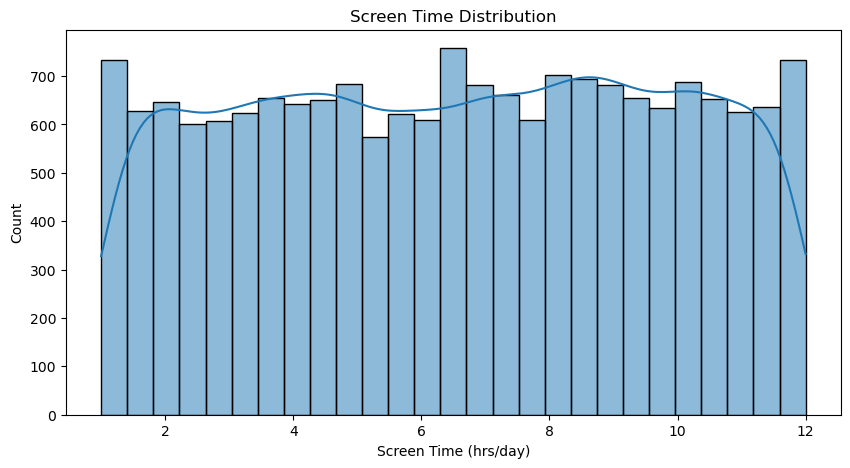

In [21]:
#EDA


#Screen Time Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    df['Screen Time (hrs/day)'],
    kde=True
)

plt.title('Screen Time Distribution')
plt.show()

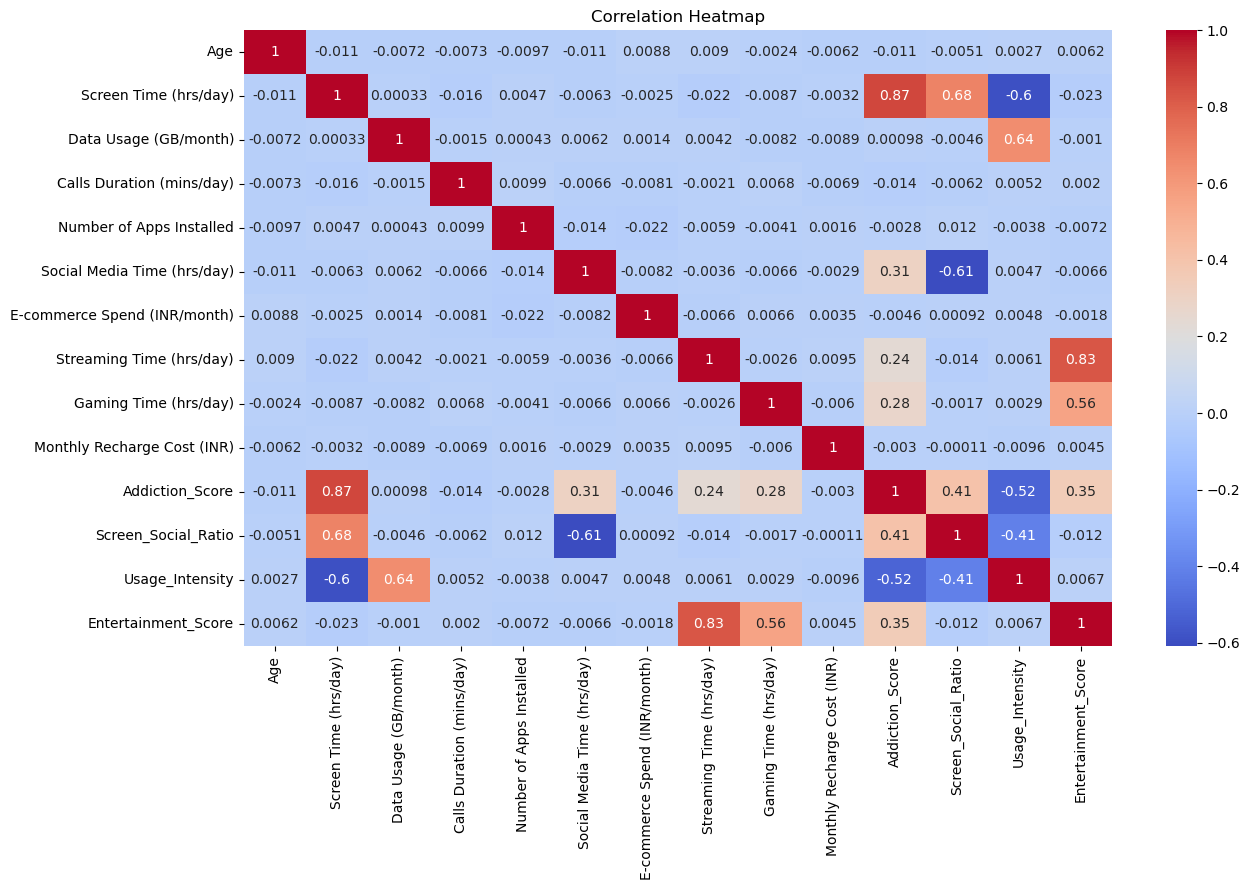

In [22]:
#Health Risk Distribution
plt.figure(figsize=(14,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

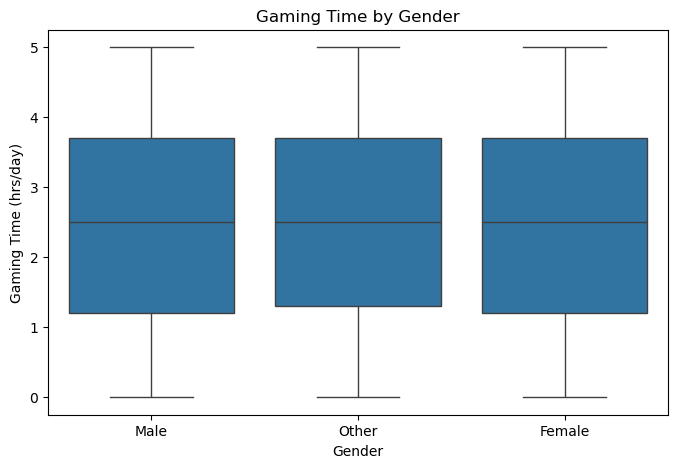

In [23]:
#Gaming Time
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Gender',
    y='Gaming Time (hrs/day)',
    data=df
)

plt.title('Gaming Time by Gender')
plt.show()

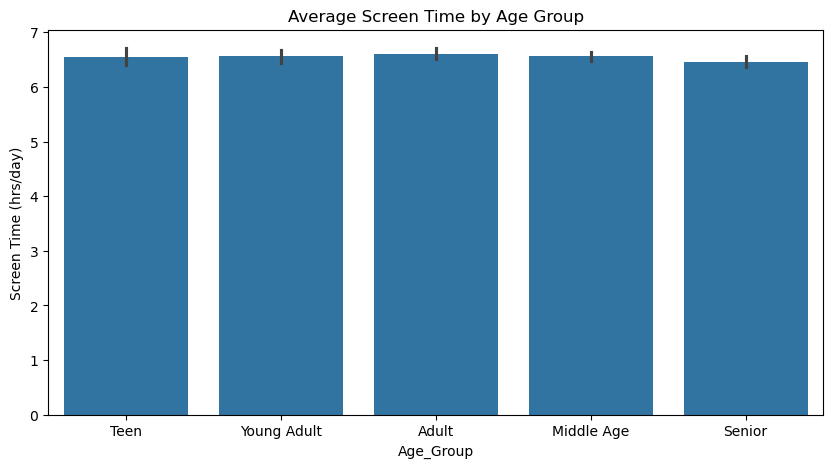

In [24]:
#Streaming Time
plt.figure(figsize=(10,5))

sns.barplot(
    x='Age_Group',
    y='Screen Time (hrs/day)',
    data=df
)

plt.title('Average Screen Time by Age Group')
plt.show()

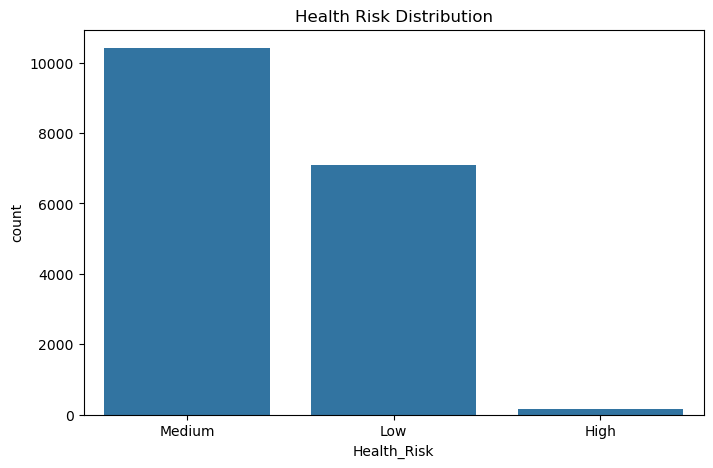

In [25]:
#Social Media Time
plt.figure(figsize=(8,5))

sns.countplot(
    x='Health_Risk',
    data=df
)

plt.title('Health Risk Distribution')
plt.show()

In [26]:
#Screen Time vs Gaming Time
fig = px.scatter(
    df,
    x='Screen Time (hrs/day)',
    y='Gaming Time (hrs/day)',
    color='Health_Risk',
    title='Screen Time vs Gaming Time'
)

fig.show()

In [27]:
#Data Encodeing
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [35]:
#Feature Selection
X = df.drop('Health_Risk', axis=1)
y = df['Health_Risk']

In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include=['object', 'category']).columns:
    X[col] = le.fit_transform(X[col].astype(str))

In [41]:
print(X.dtypes)

User ID                           int64
Age                               int64
Gender                            int64
Location                          int64
Phone Brand                       int64
OS                                int64
Screen Time (hrs/day)           float64
Data Usage (GB/month)           float64
Calls Duration (mins/day)       float64
Number of Apps Installed          int64
Social Media Time (hrs/day)     float64
E-commerce Spend (INR/month)      int64
Streaming Time (hrs/day)        float64
Gaming Time (hrs/day)           float64
Monthly Recharge Cost (INR)       int64
Primary Use                       int64
Age_Group                         int64
Addiction_Score                 float64
Screen_Social_Ratio             float64
Usage_Intensity                 float64
Entertainment_Score             float64
dtype: object


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [46]:
lr_pred = lr_model.predict(X_test)

In [47]:
#Logistic Regression Accuracy
print('Logistic Regression Accuracy:')
print(accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy:
0.9934991520633126


In [48]:
#Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [49]:
#Random Forest Prediction
rf_pred = rf_model.predict(X_test)

In [50]:
#Random Forest Accuracy
print('Random Forest Accuracy:')
print(accuracy_score(y_test, rf_pred))

Random Forest Accuracy:
0.9985867721876767


In [51]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96        34
           1       1.00      1.00      1.00      1437
           2       1.00      1.00      1.00      2067

    accuracy                           1.00      3538
   macro avg       0.99      0.98      0.98      3538
weighted avg       1.00      1.00      1.00      3538



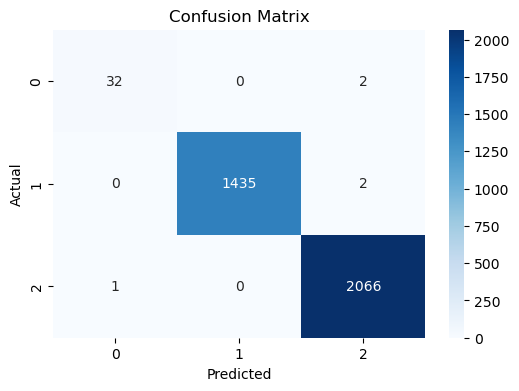

In [52]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [53]:
#XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [54]:
xgb_pred = xgb_model.predict(X_test)

In [55]:
print('XGBoost Accuracy:')
print(accuracy_score(y_test, xgb_pred))

XGBoost Accuracy:
0.9977388355002826


In [56]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                         Feature  Importance
17               Addiction_Score    0.554889
6          Screen Time (hrs/day)    0.233939
18           Screen_Social_Ratio    0.074896
19               Usage_Intensity    0.048858
10   Social Media Time (hrs/day)    0.025545
20           Entertainment_Score    0.024819
13         Gaming Time (hrs/day)    0.011401
12      Streaming Time (hrs/day)    0.007758
7          Data Usage (GB/month)    0.004928
8      Calls Duration (mins/day)    0.001774
0                        User ID    0.001726
11  E-commerce Spend (INR/month)    0.001715
14   Monthly Recharge Cost (INR)    0.001677
9       Number of Apps Installed    0.001619
1                            Age    0.001114
4                    Phone Brand    0.000843
3                       Location    0.000801
15                   Primary Use    0.000636
16                     Age_Group    0.000476
2                         Gender    0.000384
5                             OS    0.000200


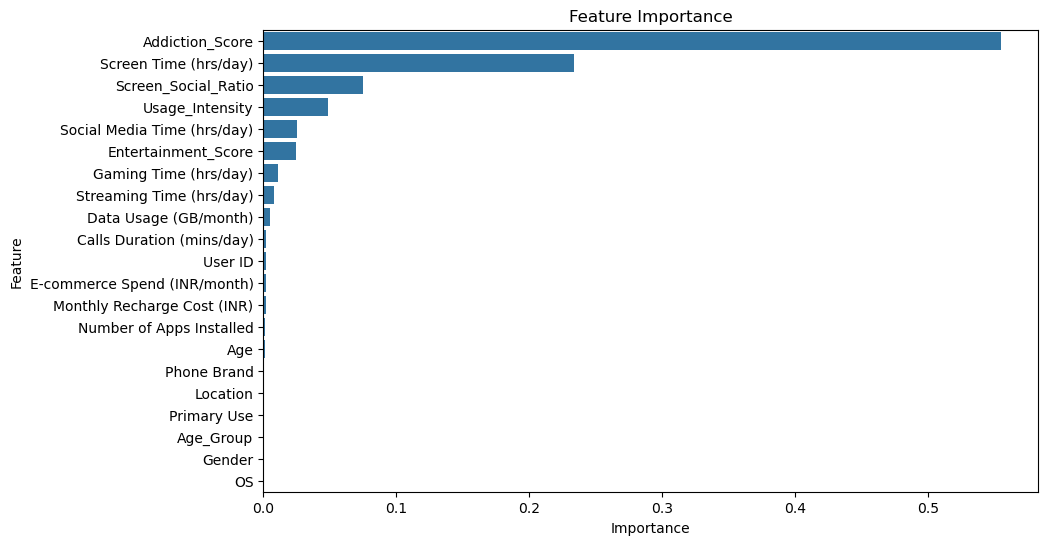

In [57]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title('Feature Importance')
plt.show()

In [58]:
cluster_data = df[[
    'Screen Time (hrs/day)',
    'Gaming Time (hrs/day)',
    'Social Media Time (hrs/day)',
    'Streaming Time (hrs/day)'
]]

In [59]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(cluster_data)


df['Cluster'] = clusters

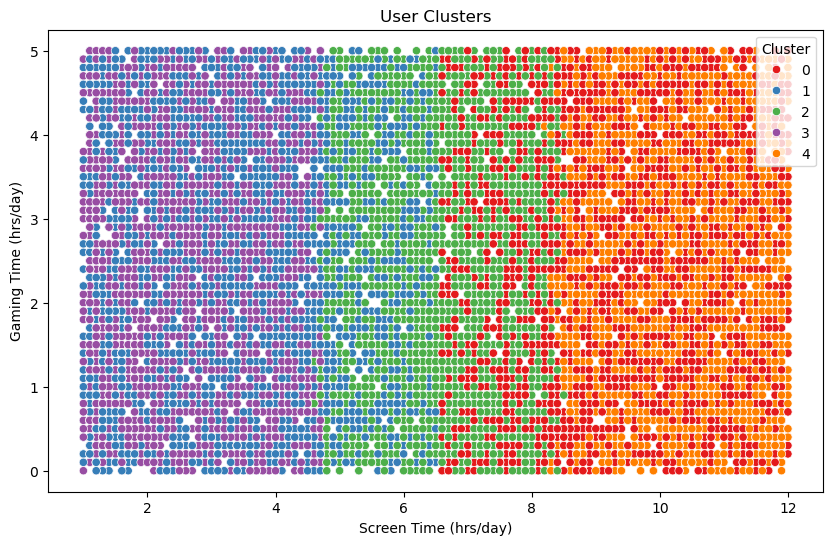

In [60]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Screen Time (hrs/day)',
    y='Gaming Time (hrs/day)',
    hue='Cluster',
    palette='Set1',
    data=df
)

plt.title('User Clusters')
plt.show()

In [61]:
def recommendation(row):

    if row['Screen Time (hrs/day)'] > 8:
        return 'Reduce screen time and take breaks.'

    elif row['Gaming Time (hrs/day)'] > 5:
        return 'Limit gaming activity.'

    elif row['Social Media Time (hrs/day)'] > 5:
        return 'Use social media timer apps.'

    elif row['Streaming Time (hrs/day)'] > 5:
        return 'Reduce binge watching.'

    else:
        return 'Healthy mobile usage pattern.'


df['Recommendation'] = df.apply(recommendation, axis=1) 

In [62]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

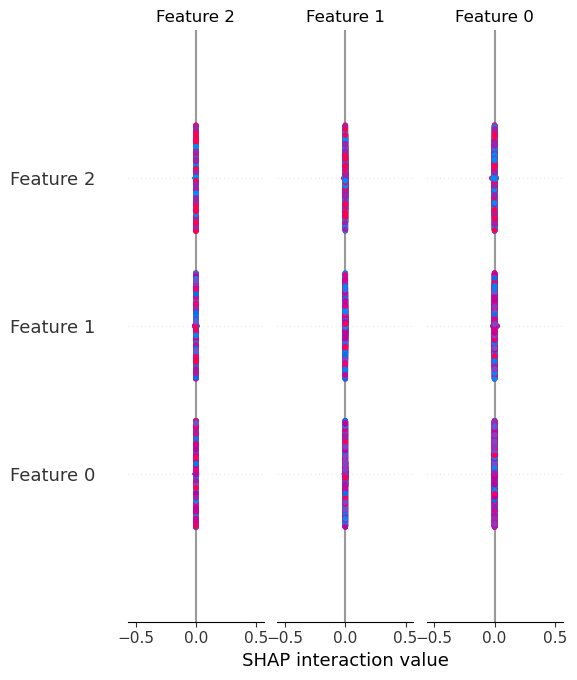

In [64]:
shap.summary_plot(shap_values, X_test)

In [65]:
joblib.dump(rf_model, 'mobile_usage_model.pkl')

['mobile_usage_model.pkl']

In [69]:
import joblib

joblib.dump(rf_model, '../models/mobile_usage_model.pkl')

['../models/mobile_usage_model.pkl']

In [70]:
model = joblib.load('../models/mobile_usage_model.pkl')

In [74]:
df.to_csv('../data/final_mobile_usage_dataset.csv', index=False)